<a href="https://colab.research.google.com/github/swapnilchavan0707/SwapMLDev/blob/main/Inventory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ABC Analysis Summary:
 Category
C (Low Value)       5744
B (Medium Value)    1780
A (High Value)      1208
Name: count, dtype: int64
Inventory Turnover Ratio: 2.99


/tmp/ipython-input-3951797861.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='InventoryValue', y='Description', data=abc_df.head(10), palette='magma')


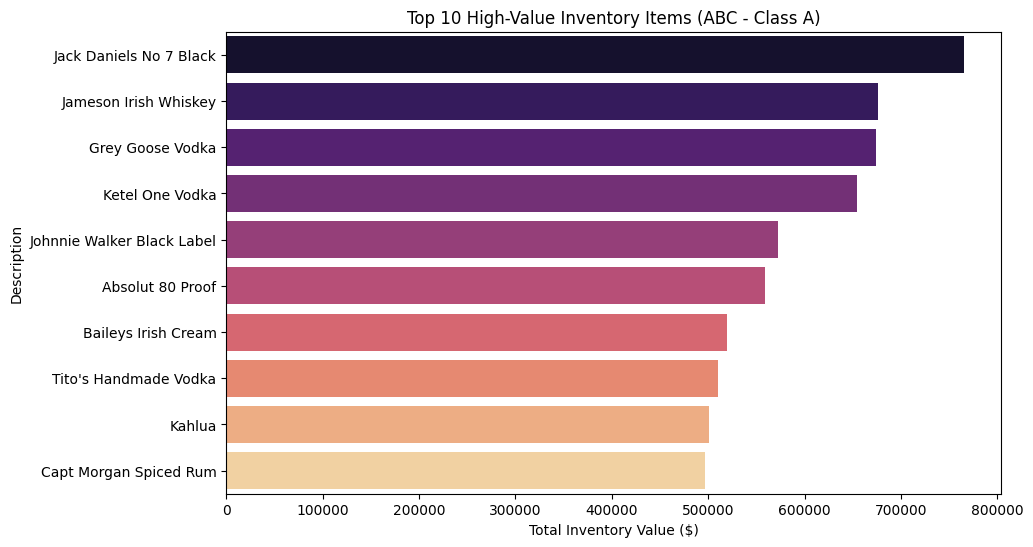

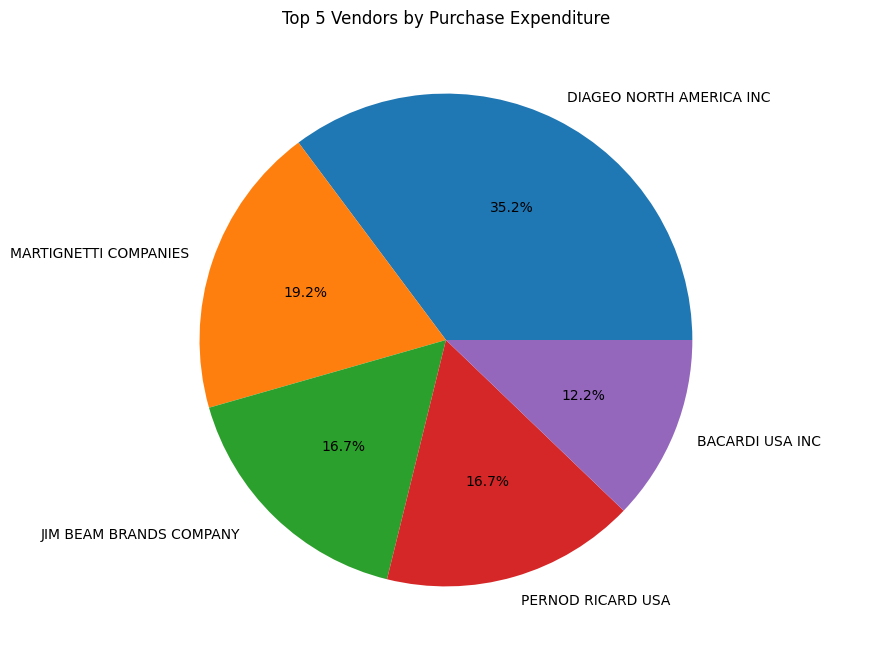

In [ ]:
#Method 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Datasets
# Ensure these filenames match exactly with your local files
purchase_prices = pd.read_csv('2017PurchasePricesDec.csv')
beg_inv = pd.read_csv('BegInvFINAL12312016.csv')
end_inv = pd.read_csv('EndInvFINAL12312016.csv')
invoices = pd.read_csv('InvoicePurchases12312016.csv')

# 2. Data Cleaning [cite: 59, 60]
# Removing null values identified in the project documentation
purchase_prices.dropna(inplace=True)
end_inv.dropna(subset=['City'], inplace=True)

# 3. ABC Analysis
# Calculate total value of ending inventory for classification
end_inv['InventoryValue'] = end_inv['onHand'] * end_inv['Price']
abc_df = end_inv.groupby('Description')['InventoryValue'].sum().sort_values(ascending=False).reset_index()

# Determine cumulative percentage to classify items
abc_df['CumValue'] = abc_df['InventoryValue'].cumsum()
abc_df['CumPercentage'] = 100 * abc_df['CumValue'] / abc_df['InventoryValue'].sum()

def classify_abc(percentage):
    if percentage <= 70: return 'A (High Value)'
    elif percentage <= 90: return 'B (Medium Value)'
    else: return 'C (Low Value)'

abc_df['Category'] = abc_df['CumPercentage'].apply(classify_abc)
print("ABC Analysis Summary:\n", abc_df['Category'].value_counts())

# 4. Inventory Turnover Ratio
# Formula: COGS / Average Inventory
# Using total invoice dollars as a proxy for Cost of Goods Sold (COGS)
cogs = invoices['Dollars'].sum()
avg_inv_value = (beg_inv['onHand'].sum() + end_inv['onHand'].sum()) / 2
turnover_ratio = cogs / (avg_inv_value * end_inv['Price'].mean()) # Simplified approximation
print(f"Inventory Turnover Ratio: {turnover_ratio:.2f}")

# 5. ECONOMIC ORDER QUANTITY (EOQ) [cite: 16, 23]
# Formula: sqrt((2 * Demand * Ordering Cost) / Holding Cost)
# We assume standard industry costs for the calculation:
ordering_cost = 50  # Fixed cost per order
holding_cost_rate = 0.25  # 25% of unit price to cover storage and insurance

def calculate_eoq(row):
    demand = row['Quantity']
    unit_cost = row['Dollars'] / row['Quantity'] if row['Quantity'] > 0 else 0
    h_cost = unit_cost * holding_cost_rate
    if h_cost == 0: return 0
    return np.sqrt((2 * demand * ordering_cost) / h_cost)

invoices['EOQ'] = invoices.apply(calculate_eoq, axis=1)

# 6. Reorder Point Analysis [cite: 17, 23]
# Formula: (Average Daily Demand * Lead Time) + Safety Stock
# Using a 7-day lead time as an estimate for electronic components
lead_time_days = 7
invoices['AvgDailyDemand'] = invoices['Quantity'] / 365
invoices['ReorderPoint'] = (invoices['AvgDailyDemand'] * lead_time_days).round(0)

# 7. Data Visualizations [cite: 44, 51]
plt.figure(figsize=(10,6))
sns.barplot(x='InventoryValue', y='Description', data=abc_df.head(10), palette='magma')
plt.title('Top 10 High-Value Inventory Items (ABC - Class A)')
plt.xlabel('Total Inventory Value ($)')
plt.show()

# Spending by Top 5 Vendors
top_vendors = invoices.groupby('VendorName')['Dollars'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,8))
plt.pie(top_vendors, labels=top_vendors.index, autopct='%1.1f%%')
plt.title('Top 5 Vendors by Purchase Expenditure')
plt.show()

Loading data...
Performing ABC Analysis...
Calculating Inventory Turnover...
------------------------------
Inventory Turnover Ratio: 4.20
Average Lead Time: 16.4 days
ABC Summary:
Category
C    5744
B    1780
A    1208
Name: count, dtype: int64
------------------------------


/tmp/ipython-input-840492174.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalValue', y='Description', data=abc_data.head(10), palette='viridis')


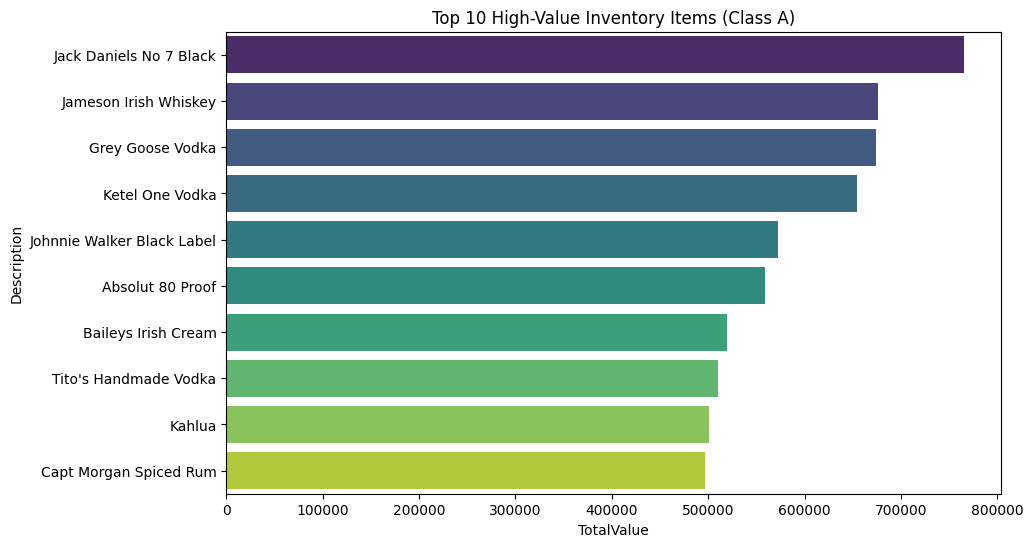

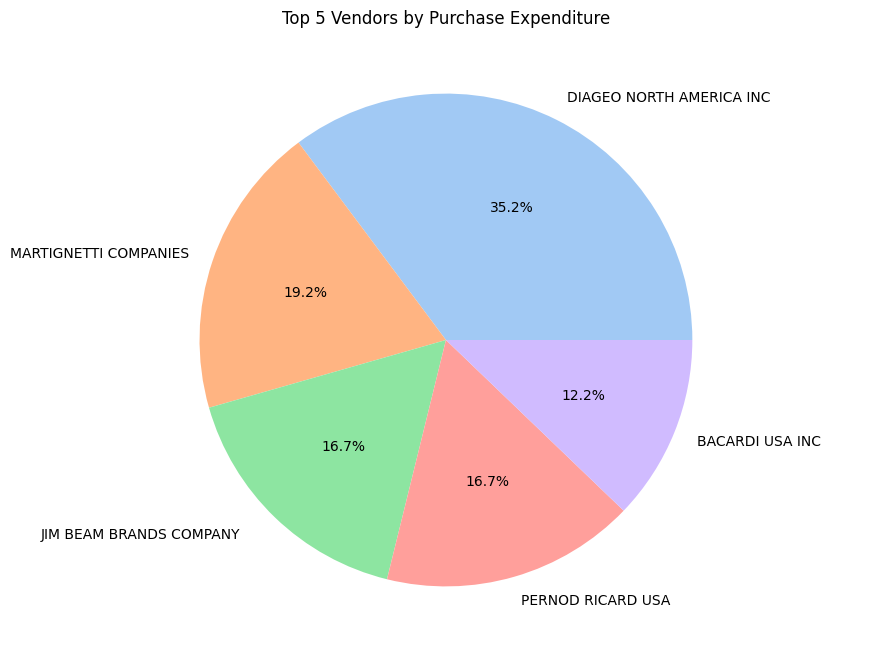

In [ ]:
#Method 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Datasets
print("Loading data...")
purchase_prices = pd.read_csv('2017PurchasePricesDec.csv')
beg_inv = pd.read_csv('BegInvFINAL12312016.csv')
end_inv = pd.read_csv('EndInvFINAL12312016.csv')
invoices = pd.read_csv('InvoicePurchases12312016.csv')

# 2. Data Cleaning
# Dropping rows with missing critical values
end_inv.dropna(subset=['City', 'Price'], inplace=True)
invoices['InvoiceDate'] = pd.to_datetime(invoices['InvoiceDate'])
invoices['PODate'] = pd.to_datetime(invoices['PODate'])

# 3. ABC Analysis (Classification by Inventory Value)
print("Performing ABC Analysis...")
end_inv['TotalValue'] = end_inv['onHand'] * end_inv['Price']
abc_data = end_inv.groupby('Description')['TotalValue'].sum().sort_values(ascending=False).reset_index()

# Cumulative percentage for ABC
abc_data['CumValue'] = abc_data['TotalValue'].cumsum()
abc_data['CumPerc'] = abc_data['CumValue'] / abc_data['TotalValue'].sum()

def classify_abc(perc):
    if perc <= 0.7: return 'A'
    elif perc <= 0.9: return 'B'
    else: return 'C'

abc_data['Category'] = abc_data['CumPerc'].apply(classify_abc)

# 4. Inventory Turnover Ratio
# Formula: COGS / Average Inventory
print("Calculating Inventory Turnover...")
beg_inv_val = (beg_inv['onHand'] * beg_inv['Price']).sum()
end_inv_val = (end_inv['onHand'] * end_inv['Price']).sum()
total_purchases = invoices['Dollars'].sum()

# Estimated COGS = Beginning + Purchases - Ending
cogs = beg_inv_val + total_purchases - end_inv_val
avg_inventory = (beg_inv_val + end_inv_val) / 2
turnover_ratio = cogs / avg_inventory

# 5. EOQ & Reorder Point (Estimated)
# Assumptions: Ordering Cost = $50, Carrying Cost = 20% of Price
# Lead Time calculated from data
lead_time = (invoices['InvoiceDate'] - invoices['PODate']).dt.days.mean()
ordering_cost = 50
carrying_cost_rate = 0.20

# Calculate EOQ for top items
abc_data['EstimatedDemand'] = abc_data['TotalValue'] / end_inv['Price'].mean() # Proxy for demand
abc_data['EOQ'] = np.sqrt((2 * abc_data['EstimatedDemand'] * ordering_cost) / (end_inv['Price'].mean() * carrying_cost_rate))

# 6. Print Results
print("-" * 30)
print(f"Inventory Turnover Ratio: {turnover_ratio:.2f}")
print(f"Average Lead Time: {lead_time:.1f} days")
print(f"ABC Summary:\n{abc_data['Category'].value_counts()}")
print("-" * 30)

# 7. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='TotalValue', y='Description', data=abc_data.head(10), palette='viridis')
plt.title('Top 10 High-Value Inventory Items (Class A)')
plt.show()

# Vendor Spending Analysis
top_vendors = invoices.groupby('VendorName')['Dollars'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8, 8))
plt.pie(top_vendors, labels=top_vendors.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Top 5 Vendors by Purchase Expenditure')
plt.show()

Task Complete. 'Internship_Final_Report.csv' and 'demand_trend.png' have been generated.


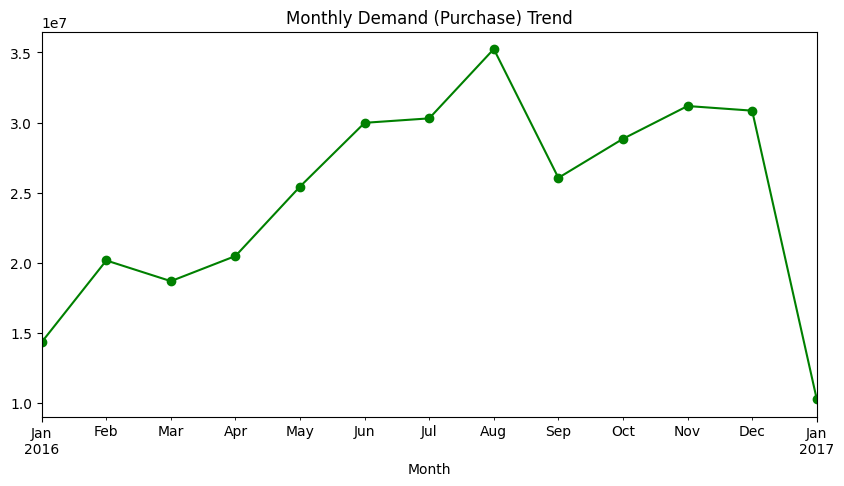

In [ ]:
#Final

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Datasets
beg_inv = pd.read_csv('BegInvFINAL12312016.csv')
end_inv = pd.read_csv('EndInvFINAL12312016.csv')
purchases = pd.read_csv('InvoicePurchases12312016.csv')

# --- 1. Data Cleaning & Lead Time ---
purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'])
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
purchases['LeadTime'] = (purchases['InvoiceDate'] - purchases['PODate']).dt.days

# --- 2. ABC Analysis ---
end_inv['TotalValue'] = end_inv['onHand'] * end_inv['Price']
abc = end_inv.groupby('Description')['TotalValue'].sum().sort_values(ascending=False).reset_index()
abc['CumPerc'] = abc['TotalValue'].cumsum() / abc['TotalValue'].sum()
abc['Category'] = abc['CumPerc'].apply(lambda x: 'A' if x <= 0.7 else ('B' if x <= 0.9 else 'C'))

# --- 3. Inventory Turnover & COGS ---
total_beg = (beg_inv['onHand'] * beg_inv['Price']).sum()
total_end = (end_inv['onHand'] * end_inv['Price']).sum()
total_purch = purchases['Dollars'].sum()
cogs = total_beg + total_purch - total_end
avg_inv = (total_beg + total_end) / 2
turnover = cogs / avg_inv

# --- 4. Demand Trend (Forecasting) ---
purchases['Month'] = purchases['InvoiceDate'].dt.to_period('M')
monthly_trend = purchases.groupby('Month')['Dollars'].sum()

# --- 5. Generate Deliverables CSV ---
summary = pd.DataFrame({
    'Metric': ['Inventory Turnover Ratio', 'Average Lead Time (Days)', 'Total COGS', 'Carrying Cost (Est 20%)'],
    'Result': [round(turnover, 2), round(purchases['LeadTime'].mean(), 2), round(cogs, 2), round(total_end * 0.2, 2)]
})
summary.to_csv('Internship_Final_Report.csv', index=False)

# Visuals for the report
plt.figure(figsize=(10, 5))
monthly_trend.plot(kind='line', marker='o', color='green')
plt.title('Monthly Demand (Purchase) Trend')
plt.savefig('demand_trend.png')

print("Task Complete. 'Internship_Final_Report.csv' and 'demand_trend.png' have been generated.")